In [1]:
import os
import pandas as pd
import numpy as np
import csv
import time
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import pearsonr
import seaborn as sns
import pybaseball as bb
import datetime
from pybaseball import statcast_pitcher_percentile_ranks
from pybaseball import statcast_pitcher_spin_dir_comp
from pybaseball import statcast_pitcher_arsenal_stats
import requests
import json
from typing import Dict, Any, Optional, List, Union
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed

In [2]:
from pybaseball import batting_stats, statcast

# As of now, 2025 MLB data may not be available yet. If so, the returned DataFrame will be empty.
# If available, get the list of MLB batters in 2025, their at-bat totals:
batting_2025 = batting_stats(2025, qual=0)

# Filter to batters with more than 100 AB, if data is available
if not batting_2025.empty and 'AB' in batting_2025.columns:
    batters_over_100ab = batting_2025[batting_2025['AB'] > 100].copy()
else:
    batters_over_100ab = pd.DataFrame()

# Get all Statcast batter data for 2025 using statcast(), which returns all events for both batters and pitchers
statcast_2025 = statcast('2025-03-20', '2025-10-05')

# If we want only batters with > 100 AB, we need their MLBAM IDs.
# The 'batter' column in Statcast is the MLBAM ID, but we need to map our list of batters to MLBAMs.
# Use playerid_lookup as needed, but first try inference from the batting dataframe (which sometimes has MLBAM or Name).

mlbam_ids = set()
if not batters_over_100ab.empty:
    # Common columns: 'IDfg' (FanGraphs), maybe 'MLBAMID', sometimes just a 'playerid' column
    # Try to get MLBAM IDs
    if 'IDfg' in batters_over_100ab.columns and batters_over_100ab['IDfg'].dtype == np.int64:
        # Sometimes will be MLBAM ID, but often FanGraphs ID.
        pass

    # Look for MLBAM ID column
    if 'MLBAMID' in batters_over_100ab.columns:
        mlbam_ids = set(batters_over_100ab['MLBAMID'].dropna().astype(int).tolist())
    elif 'IDfg' in batters_over_100ab.columns:
        # Might be possible, but usually need to crosswalk via playerid_lookup
        # Try to use first and last names if available
        name_col = None
        for col in ['Name', 'name', 'Player', 'player_name']:
            if col in batters_over_100ab.columns:
                name_col = col
                break
        if name_col:
            import pybaseball
            for row in batters_over_100ab.itertuples():
                name_val = getattr(row, name_col)
                # Name may or may not contain a comma; be robust
                if isinstance(name_val, str) and ',' in name_val:
                    parts = name_val.split(',')
                    if len(parts) >= 2:
                        last_name = parts[0].strip()
                        first_name = parts[1].strip()
                        try:
                            lookup_res = pybaseball.playerid_lookup(last_name, first_name)
                            if not lookup_res.empty and 'key_mlbam' in lookup_res.columns:
                                mlbam = lookup_res.iloc[0]['key_mlbam']
                                if pd.notnull(mlbam):
                                    mlbam_ids.add(int(mlbam))
                        except Exception:
                            continue
                elif isinstance(name_val, str) and ' ' in name_val:
                    # "First Last" style
                    parts = name_val.strip().split(' ')
                    first_name = parts[0]
                    last_name = ' '.join(parts[1:]) if len(parts) > 1 else ''
                    try:
                        lookup_res = pybaseball.playerid_lookup(last_name, first_name)
                        if not lookup_res.empty and 'key_mlbam' in lookup_res.columns:
                            mlbam = lookup_res.iloc[0]['key_mlbam']
                            if pd.notnull(mlbam):
                                mlbam_ids.add(int(mlbam))
                    except Exception:
                        continue

# Now filter Statcast 2025 data for these qualifying batters (by MLBAM id)
if not statcast_2025.empty and len(mlbam_ids) > 0:
    qualified_batter_data = statcast_2025[statcast_2025['batter'].isin(mlbam_ids)].copy()
else:
    qualified_batter_data = pd.DataFrame()

# The resulting DataFrame is qualified_batter_data






This is a large query, it may take a moment to complete


/Users/gmarrero/Desktop/Personal_Projects/.venv/lib/python3.12/site-packages/pybaseball/statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)
  0%|          | 0/200 [00:00<?, ?it/s]/Users/gmarrero/Desktop/Personal_Projects/.venv/lib/python3.12/site-packages/pybaseball/datahelpers/postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `err

Gathering player lookup table. This may take a moment.


In [28]:
qualified_batter_data

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
279,ST,2025-10-05,85.8,-1.74,5.43,"Domínguez, Seranthony",519317,622554,strikeout,swinging_strike_blocked,...,2,3.36,-0.83,-0.83,34.9,27.010447,-34.611914,35.262469,54.418407,51.40176
286,ST,2025-10-05,86.0,-1.89,5.48,"Domínguez, Seranthony",519317,622554,NaN,swinging_strike,...,2,3.3,-1.32,-1.32,32.2,22.633588,-22.295716,27.994395,56.565213,38.075789
294,SI,2025-10-05,97.3,-1.9,5.38,"Domínguez, Seranthony",519317,622554,NaN,foul,...,2,1.93,1.22,1.22,28.1,14.496536,-12.81057,32.13088,35.081774,26.83396
299,FS,2025-10-05,87.2,-1.48,5.56,"Domínguez, Seranthony",700250,622554,walk,ball,...,2,2.28,0.49,-0.49,34.4,<NA>,<NA>,<NA>,<NA>,<NA>
309,FS,2025-10-05,85.8,-1.73,5.57,"Domínguez, Seranthony",700250,622554,NaN,ball,...,2,2.68,0.35,-0.35,34.9,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2653,CH,2025-03-20,85.6,-2.95,5.96,"Gallen, Zac",668709,668678,NaN,foul,...,<NA>,2.54,1.28,-1.28,<NA>,2.980125,16.256897,35.927016,46.732727,13.131604
2784,FC,2025-03-20,89.6,-2.96,6.07,"Gallen, Zac",668709,668678,NaN,called_strike,...,<NA>,2.05,-0.21,0.21,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2898,FF,2025-03-20,93.4,-2.78,6.13,"Gallen, Zac",668709,668678,NaN,ball,...,<NA>,1.19,0.78,-0.78,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3027,KC,2025-03-20,79.1,-3.06,6.1,"Gallen, Zac",669127,668678,single,hit_into_play,...,<NA>,4.38,-0.41,-0.41,<NA>,22.502899,0.433199,31.98632,44.487963,39.696136


In [29]:
# Remove rows where 'release_speed' is NA
qualified_batter_data = qualified_batter_data[qualified_batter_data['release_speed'].notna()]
qualified_batter_data = qualified_batter_data[qualified_batter_data['player_name'].notna()]
qualified_batter_data = qualified_batter_data[qualified_batter_data['batter'].notna()]
qualified_batter_data = qualified_batter_data[qualified_batter_data['pitcher'].notna()]

# Display number of rows removed (optional, for verification)
# num_na_release_speed = qualified_batter_data['release_speed'].isna().sum()
# num_na_release_speed

qualified_batter_data

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
279,ST,2025-10-05,85.8,-1.74,5.43,"Domínguez, Seranthony",519317,622554,strikeout,swinging_strike_blocked,...,2,3.36,-0.83,-0.83,34.9,27.010447,-34.611914,35.262469,54.418407,51.40176
286,ST,2025-10-05,86.0,-1.89,5.48,"Domínguez, Seranthony",519317,622554,NaN,swinging_strike,...,2,3.3,-1.32,-1.32,32.2,22.633588,-22.295716,27.994395,56.565213,38.075789
294,SI,2025-10-05,97.3,-1.9,5.38,"Domínguez, Seranthony",519317,622554,NaN,foul,...,2,1.93,1.22,1.22,28.1,14.496536,-12.81057,32.13088,35.081774,26.83396
299,FS,2025-10-05,87.2,-1.48,5.56,"Domínguez, Seranthony",700250,622554,walk,ball,...,2,2.28,0.49,-0.49,34.4,<NA>,<NA>,<NA>,<NA>,<NA>
309,FS,2025-10-05,85.8,-1.73,5.57,"Domínguez, Seranthony",700250,622554,NaN,ball,...,2,2.68,0.35,-0.35,34.9,<NA>,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2653,CH,2025-03-20,85.6,-2.95,5.96,"Gallen, Zac",668709,668678,NaN,foul,...,<NA>,2.54,1.28,-1.28,<NA>,2.980125,16.256897,35.927016,46.732727,13.131604
2784,FC,2025-03-20,89.6,-2.96,6.07,"Gallen, Zac",668709,668678,NaN,called_strike,...,<NA>,2.05,-0.21,0.21,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2898,FF,2025-03-20,93.4,-2.78,6.13,"Gallen, Zac",668709,668678,NaN,ball,...,<NA>,1.19,0.78,-0.78,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3027,KC,2025-03-20,79.1,-3.06,6.1,"Gallen, Zac",669127,668678,single,hit_into_play,...,<NA>,4.38,-0.41,-0.41,<NA>,22.502899,0.433199,31.98632,44.487963,39.696136


In [30]:
# Create a dataframe for plate appearances vs right-handed pitchers
rhp_data = qualified_batter_data[qualified_batter_data['p_throws'] == 'R'].copy()

 
#judge_vs_rhp.head()

arm_angle_stats = rhp_data['arm_angle'].agg(['count', 'min', 'max', 'mean', 'std'])
arm_angle_stats['range'] = arm_angle_stats['max'] - arm_angle_stats['min']
print("Arm Angle Summary Statistics (vs_rhp):")
print(arm_angle_stats)

Arm Angle Summary Statistics (vs_rhp):
count    410312.000000
min         -67.400000
max          87.100000
mean         37.540851
std          12.644122
range       154.500000
Name: arm_angle, dtype: float64


In [31]:
rhp_data['events'].value_counts()

events
field_out                    43298
strikeout                    23508
single                       15219
walk                          8987
double                        4581
home_run                      3491
force_out                     1799
grounded_into_double_play     1798
hit_by_pitch                  1146
sac_fly                        743
field_error                    584
triple                         394
sac_bunt                       258
double_play                    234
fielders_choice                214
truncated_pa                   195
fielders_choice_out            166
strikeout_double_play           82
catcher_interf                  57
sac_fly_double_play             11
Name: count, dtype: int64

In [32]:
# Create a dataframe for plate appearances vs right-handed pitchers
lhp_data = qualified_batter_data[qualified_batter_data['p_throws'] == 'L'].copy()

 
#judge_vs_rhp.head()

arm_angle_stats = lhp_data['arm_angle'].agg(['count', 'min', 'max', 'mean', 'std'])
arm_angle_stats['range'] = arm_angle_stats['max'] - arm_angle_stats['min']
print("Arm Angle Summary Statistics (vs_lhp):")
print(arm_angle_stats)

Arm Angle Summary Statistics (vs_lhp):
count    152627.000000
min         -32.700000
max          77.700000
mean         38.150778
std          13.405642
range       110.400000
Name: arm_angle, dtype: float64


In [33]:
lhp_data['events'].value_counts()

events
field_out                    15957
strikeout                     9025
single                        5789
walk                          3149
double                        1669
home_run                      1182
force_out                      816
grounded_into_double_play      682
hit_by_pitch                   385
sac_fly                        278
field_error                    242
triple                         127
sac_bunt                       122
fielders_choice                 76
fielders_choice_out             75
double_play                     69
truncated_pa                    63
strikeout_double_play           13
catcher_interf                   9
sac_fly_double_play              2
triple_play                      1
Name: count, dtype: int64

In [34]:
# Define the bins and labels for arm angle
arm_angle_bins_custom = [-float('inf'), 20, 30, 40, 50, float('inf')]

lhp_data['arm_angle_bin'] = pd.cut(lhp_data['arm_angle'], bins=arm_angle_bins_custom, right=False)

# Count occurrences of each bin
arm_angle_counts_lhp = lhp_data['arm_angle_bin'].value_counts().sort_index()

arm_angle_counts_lhp

arm_angle_bin
[-inf, 20.0)    13120
[20.0, 30.0)    22042
[30.0, 40.0)    44788
[40.0, 50.0)    44627
[50.0, inf)     28050
Name: count, dtype: int64

In [35]:
rhp_data['arm_angle_bin'] = pd.cut(rhp_data['arm_angle'], bins=arm_angle_bins_custom, right=False)

# Count occurrences of each bin
arm_angle_counts_rhp = rhp_data['arm_angle_bin'].value_counts().sort_index()

arm_angle_counts_rhp

arm_angle_bin
[-inf, 20.0)     29267
[20.0, 30.0)     72293
[30.0, 40.0)    127905
[40.0, 50.0)    120220
[50.0, inf)      60627
Name: count, dtype: int64

/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_43330/2499952065.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arm_angle_event_counts_lhp = lhp_data.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)


<Figure size 1200x800 with 0 Axes>

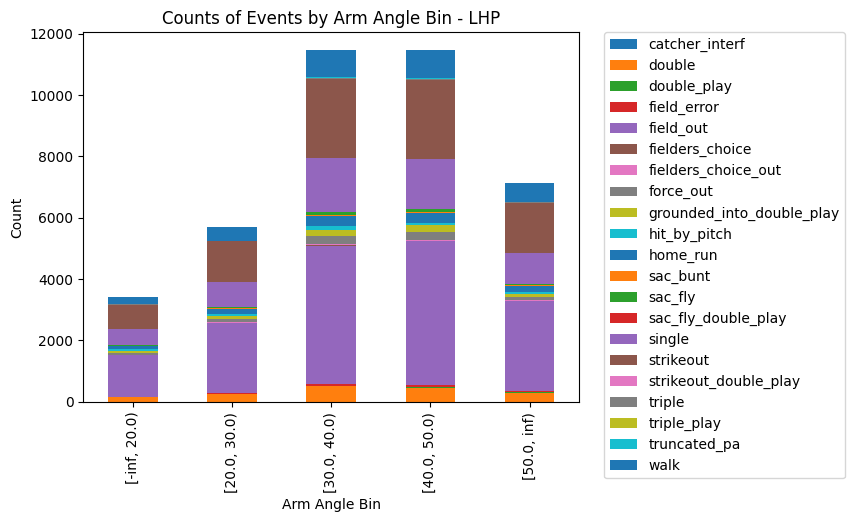

In [36]:
# Group by 'arm_angle_bin' and 'events', then count the occurrences
arm_angle_event_counts_lhp = lhp_data.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)
arm_angle_event_counts_lhp
# Create a bar plot of the counts
plt.figure(figsize=(12, 8))
arm_angle_event_counts_lhp.plot(kind='bar', stacked=True)
plt.title('Counts of Events by Arm Angle Bin - LHP')
plt.xlabel('Arm Angle Bin')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_43330/2702709294.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arm_angle_event_counts_rhp = rhp_data.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)


<Figure size 1200x800 with 0 Axes>

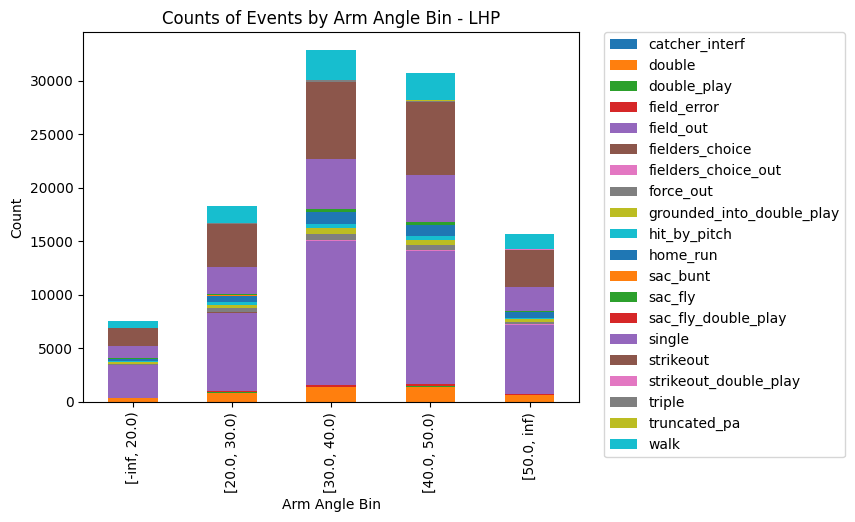

In [37]:
# Group by 'arm_angle_bin' and 'events', then count the occurrences
arm_angle_event_counts_rhp = rhp_data.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)
arm_angle_event_counts_rhp
# Create a bar plot of the counts
plt.figure(figsize=(12, 8))
arm_angle_event_counts_rhp.plot(kind='bar', stacked=True)
plt.title('Counts of Events by Arm Angle Bin - LHP')
plt.xlabel('Arm Angle Bin')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

In [38]:
arm_angle_event_counts_lhp = arm_angle_event_counts_lhp.reindex(sorted(arm_angle_event_counts_lhp.columns), axis=1)
arm_angle_event_counts_lhp

events,catcher_interf,double,double_play,field_error,field_out,fielders_choice,fielders_choice_out,force_out,grounded_into_double_play,hit_by_pitch,...,sac_bunt,sac_fly,sac_fly_double_play,single,strikeout,strikeout_double_play,triple,triple_play,truncated_pa,walk
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",1,143,7,23,1344,5,9,74,54,56,...,15,21,0,502,811,1,14,0,8,234
"[20.0, 30.0)",3,246,14,36,2273,12,9,104,87,82,...,25,35,0,819,1323,3,16,0,5,437
"[30.0, 40.0)",4,501,20,58,4504,25,26,255,206,118,...,35,87,1,1748,2585,2,32,0,21,895
"[40.0, 50.0)",0,454,17,78,4690,18,19,256,217,89,...,29,79,1,1647,2559,5,39,1,23,911
"[50.0, inf)",1,302,11,38,2929,16,10,117,105,38,...,17,55,0,1003,1621,2,23,0,5,627


In [39]:
arm_angle_event_counts_rhp = arm_angle_event_counts_rhp.reindex(sorted(arm_angle_event_counts_rhp.columns), axis=1)
arm_angle_event_counts_rhp

events,catcher_interf,double,double_play,field_error,field_out,fielders_choice,fielders_choice_out,force_out,grounded_into_double_play,hit_by_pitch,home_run,sac_bunt,sac_fly,sac_fly_double_play,single,strikeout,strikeout_double_play,triple,truncated_pa,walk
arm_angle_bin,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",1,330,14,47,3007,16,14,121,126,101,232,25,56,0,1145,1621,8,37,16,622
"[20.0, 30.0)",9,842,44,120,7322,34,29,331,335,224,603,46,110,3,2515,4053,19,59,31,1593
"[30.0, 40.0)",17,1334,73,153,13407,72,47,576,563,389,1058,74,228,4,4681,7221,19,117,61,2789
"[40.0, 50.0)",21,1369,68,171,12444,59,43,486,488,300,1039,65,221,3,4375,6814,24,124,57,2506
"[50.0, inf)",9,625,30,86,6434,33,31,255,253,108,491,44,115,1,2253,3454,10,52,28,1327


In [40]:
# Ensure all columns from qualified_batter_data['events'] are present in arm_angle_event_counts_lhp (add with 0s if missing)
all_events = qualified_batter_data['events'].unique()
# Ensure all columns from all_events are present in arm_angle_event_counts_lhp (add missing ones, fill with 0)
for event in all_events:
    if event not in arm_angle_event_counts_lhp.columns:
        arm_angle_event_counts_lhp[event] = 0
# Reorder columns to match all_events order
arm_angle_event_counts_lhp = arm_angle_event_counts_lhp.reindex(columns=all_events, fill_value=0)
arm_angle_event_counts_lhp

events,strikeout,NaN,walk,field_out,double,single,sac_fly,home_run,grounded_into_double_play,fielders_choice,...,hit_by_pitch,field_error,fielders_choice_out,sac_bunt,truncated_pa,triple,strikeout_double_play,catcher_interf,sac_fly_double_play,triple_play
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",811,0,234,1344,143,502,21,105,54,5,...,56,23,9,15,8,14,1,1,0,0
"[20.0, 30.0)",1323,0,437,2273,246,819,35,165,87,12,...,82,36,9,25,5,16,3,3,0,0
"[30.0, 40.0)",2585,0,895,4504,501,1748,87,350,206,25,...,118,58,26,35,21,32,2,4,1,0
"[40.0, 50.0)",2559,0,911,4690,454,1647,79,332,217,18,...,89,78,19,29,23,39,5,0,1,1
"[50.0, inf)",1621,0,627,2929,302,1003,55,211,105,16,...,38,38,10,17,5,23,2,1,0,0


In [41]:
# Ensure all columns from qualified_batter_data['events'] are present in arm_angle_event_counts_lhp (add with 0s if missing)
all_events = qualified_batter_data['events'].unique()
# Ensure all columns from all_events are present in arm_angle_event_counts_lhp (add missing ones, fill with 0)
for event in all_events:
    if event not in arm_angle_event_counts_rhp.columns:
        arm_angle_event_counts_rhp[event] = 0
# Reorder columns to match all_events order
arm_angle_event_counts_rhp = arm_angle_event_counts_rhp.reindex(columns=all_events, fill_value=0)
arm_angle_event_counts_rhp

events,strikeout,NaN,walk,field_out,double,single,sac_fly,home_run,grounded_into_double_play,fielders_choice,...,hit_by_pitch,field_error,fielders_choice_out,sac_bunt,truncated_pa,triple,strikeout_double_play,catcher_interf,sac_fly_double_play,triple_play
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",1621,0,622,3007,330,1145,56,232,126,16,...,101,47,14,25,16,37,8,1,0,0
"[20.0, 30.0)",4053,0,1593,7322,842,2515,110,603,335,34,...,224,120,29,46,31,59,19,9,3,0
"[30.0, 40.0)",7221,0,2789,13407,1334,4681,228,1058,563,72,...,389,153,47,74,61,117,19,17,4,0
"[40.0, 50.0)",6814,0,2506,12444,1369,4375,221,1039,488,59,...,300,171,43,65,57,124,24,21,3,0
"[50.0, inf)",3454,0,1327,6434,625,2253,115,491,253,33,...,108,86,31,44,28,52,10,9,1,0


In [42]:
arm_angle_event_counts_lhp.columns

Index([                'strikeout',                         nan,
                            'walk',                 'field_out',
                          'double',                    'single',
                         'sac_fly',                  'home_run',
       'grounded_into_double_play',           'fielders_choice',
                       'force_out',               'double_play',
                    'hit_by_pitch',               'field_error',
             'fielders_choice_out',                  'sac_bunt',
                    'truncated_pa',                    'triple',
           'strikeout_double_play',            'catcher_interf',
             'sac_fly_double_play',               'triple_play'],
      dtype='object', name='events')

In [43]:
arm_angle_event_counts_lhp['strikeout'] = arm_angle_event_counts_lhp['strikeout'] + arm_angle_event_counts_lhp['strikeout_double_play']
arm_angle_event_counts_lhp['field_out'] = arm_angle_event_counts_lhp['field_out'] + arm_angle_event_counts_lhp['fielders_choice']
arm_angle_event_counts_lhp['sac_fly'] = arm_angle_event_counts_lhp['sac_fly'] + arm_angle_event_counts_lhp['sac_fly_double_play']
arm_angle_event_counts_lhp['double_play'] = arm_angle_event_counts_lhp['double_play'] + arm_angle_event_counts_lhp['grounded_into_double_play']

arm_angle_event_counts_lhp.drop(columns=['truncated_pa', 'catcher_interf','fielders_choice', 'strikeout_double_play', 'grounded_into_double_play', 'sac_fly_double_play', np.nan], inplace=True)

arm_angle_event_counts_lhp

events,strikeout,walk,field_out,double,single,sac_fly,home_run,force_out,double_play,hit_by_pitch,field_error,fielders_choice_out,sac_bunt,triple,triple_play
arm_angle_bin,,,,,,,,,,,,,,,
"[-inf, 20.0)",812,234,1349,143,502,21,105,74,61,56,23,9,15,14,0
"[20.0, 30.0)",1326,437,2285,246,819,35,165,104,101,82,36,9,25,16,0
"[30.0, 40.0)",2587,895,4529,501,1748,88,350,255,226,118,58,26,35,32,0
"[40.0, 50.0)",2564,911,4708,454,1647,80,332,256,234,89,78,19,29,39,1
"[50.0, inf)",1623,627,2945,302,1003,55,211,117,116,38,38,10,17,23,0


In [44]:
arm_angle_event_counts_lhp = arm_angle_event_counts_lhp.reindex(sorted(arm_angle_event_counts_lhp.columns), axis=1)
arm_angle_event_counts_lhp

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,sac_bunt,sac_fly,single,strikeout,triple,triple_play,walk
arm_angle_bin,,,,,,,,,,,,,,,
"[-inf, 20.0)",143,61,23,1349,9,74,56,105,15,21,502,812,14,0,234
"[20.0, 30.0)",246,101,36,2285,9,104,82,165,25,35,819,1326,16,0,437
"[30.0, 40.0)",501,226,58,4529,26,255,118,350,35,88,1748,2587,32,0,895
"[40.0, 50.0)",454,234,78,4708,19,256,89,332,29,80,1647,2564,39,1,911
"[50.0, inf)",302,116,38,2945,10,117,38,211,17,55,1003,1623,23,0,627


In [45]:
arm_angle_event_counts_rhp['strikeout'] = arm_angle_event_counts_rhp['strikeout'] + arm_angle_event_counts_rhp['strikeout_double_play']
arm_angle_event_counts_rhp['field_out'] = arm_angle_event_counts_rhp['field_out'] + arm_angle_event_counts_rhp['fielders_choice']
arm_angle_event_counts_rhp['sac_fly'] = arm_angle_event_counts_rhp['sac_fly'] + arm_angle_event_counts_rhp['sac_fly_double_play']
arm_angle_event_counts_rhp['double_play'] = arm_angle_event_counts_rhp['double_play'] + arm_angle_event_counts_rhp['grounded_into_double_play']

arm_angle_event_counts_rhp.drop(columns=['truncated_pa', 'catcher_interf','fielders_choice', 'strikeout_double_play', 'grounded_into_double_play', 'sac_fly_double_play', np.nan], inplace=True)

arm_angle_event_counts_rhp

events,strikeout,walk,field_out,double,single,sac_fly,home_run,force_out,double_play,hit_by_pitch,field_error,fielders_choice_out,sac_bunt,triple,triple_play
arm_angle_bin,,,,,,,,,,,,,,,
"[-inf, 20.0)",1629,622,3023,330,1145,56,232,121,140,101,47,14,25,37,0
"[20.0, 30.0)",4072,1593,7356,842,2515,113,603,331,379,224,120,29,46,59,0
"[30.0, 40.0)",7240,2789,13479,1334,4681,232,1058,576,636,389,153,47,74,117,0
"[40.0, 50.0)",6838,2506,12503,1369,4375,224,1039,486,556,300,171,43,65,124,0
"[50.0, inf)",3464,1327,6467,625,2253,116,491,255,283,108,86,31,44,52,0


In [46]:
arm_angle_event_counts_rhp = arm_angle_event_counts_rhp.reindex(sorted(arm_angle_event_counts_rhp.columns), axis=1)
arm_angle_event_counts_rhp.columns

Index(['double', 'double_play', 'field_error', 'field_out',
       'fielders_choice_out', 'force_out', 'hit_by_pitch', 'home_run',
       'sac_bunt', 'sac_fly', 'single', 'strikeout', 'triple', 'triple_play',
       'walk'],
      dtype='object', name='events')

In [47]:
arm_angle_event_counts_lhp

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,sac_bunt,sac_fly,single,strikeout,triple,triple_play,walk
arm_angle_bin,,,,,,,,,,,,,,,
"[-inf, 20.0)",143,61,23,1349,9,74,56,105,15,21,502,812,14,0,234
"[20.0, 30.0)",246,101,36,2285,9,104,82,165,25,35,819,1326,16,0,437
"[30.0, 40.0)",501,226,58,4529,26,255,118,350,35,88,1748,2587,32,0,895
"[40.0, 50.0)",454,234,78,4708,19,256,89,332,29,80,1647,2564,39,1,911
"[50.0, inf)",302,116,38,2945,10,117,38,211,17,55,1003,1623,23,0,627


In [48]:
arm_angle_event_counts_rhp

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,sac_bunt,sac_fly,single,strikeout,triple,triple_play,walk
arm_angle_bin,,,,,,,,,,,,,,,
"[-inf, 20.0)",330,140,47,3023,14,121,101,232,25,56,1145,1629,37,0,622
"[20.0, 30.0)",842,379,120,7356,29,331,224,603,46,113,2515,4072,59,0,1593
"[30.0, 40.0)",1334,636,153,13479,47,576,389,1058,74,232,4681,7240,117,0,2789
"[40.0, 50.0)",1369,556,171,12503,43,486,300,1039,65,224,4375,6838,124,0,2506
"[50.0, inf)",625,283,86,6467,31,255,108,491,44,116,2253,3464,52,0,1327


In [49]:
# Calculate the total number of events in each row for LHP and RHP event counts
arm_angle_event_counts_lhp['total_events'] = arm_angle_event_counts_lhp.sum(axis=1)
arm_angle_event_counts_rhp['total_events'] = arm_angle_event_counts_rhp.sum(axis=1)

In [50]:
arm_angle_event_counts_rhp

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,sac_bunt,sac_fly,single,strikeout,triple,triple_play,walk,total_events
arm_angle_bin,,,,,,,,,,,,,,,,
"[-inf, 20.0)",330,140,47,3023,14,121,101,232,25,56,1145,1629,37,0,622,7522
"[20.0, 30.0)",842,379,120,7356,29,331,224,603,46,113,2515,4072,59,0,1593,18282
"[30.0, 40.0)",1334,636,153,13479,47,576,389,1058,74,232,4681,7240,117,0,2789,32805
"[40.0, 50.0)",1369,556,171,12503,43,486,300,1039,65,224,4375,6838,124,0,2506,30599
"[50.0, inf)",625,283,86,6467,31,255,108,491,44,116,2253,3464,52,0,1327,15602


In [ ]:
# Create a copy so that we don't overwrite the original
lhp_ba = arm_angle_event_counts_lhp.copy()

# Calculate numerator: hits (single, double, triple, home_run)
hits_cols = ['single', 'double', 'triple', 'home_run']

lhp_ba['hits'] = lhp_ba[hits_cols].sum(axis=1)

lhp_ba['Batting_Average'] = lhp_ba['hits'] / (lhp_ba['hits'] + lhp_ba['double_play'] + lhp_ba['field_error'] + lhp_ba['field_out'] + lhp_ba['fielders_choice_out'] + lhp_ba['force_out'] + lhp_ba['strikeout'] + lhp_ba['triple_play'])

lhp_ba['Slugging_Percentage'] = ((lhp_ba['home_run'] * 4) + (lhp_ba['double'] * 2) + (lhp_ba['triple'] * 3) + (lhp_ba['single'] * 1)) / (lhp_ba['hits'] + lhp_ba['double_play'] + lhp_ba['field_error'] + lhp_ba['field_out'] + lhp_ba['fielders_choice_out'] + lhp_ba['force_out'] + lhp_ba['strikeout'] + lhp_ba['triple_play'])

lhp_ba['On_Base_Percentage'] = (lhp_ba['hits'] + lhp_ba['walk'] + lhp_ba['hit_by_pitch']) / (lhp_ba['hits'] + lhp_ba['double_play'] + lhp_ba['field_error'] + lhp_ba['field_out'] + lhp_ba['fielders_choice_out'] + lhp_ba['force_out'] + lhp_ba['strikeout'] + lhp_ba['triple_play'])

lhp_ba['On_Base_Plus_Slugging'] = lhp_ba['On_Base_Percentage'] + lhp_ba['Slugging_Percentage']






lhp_ba['K_Rate'] = ((lhp_ba['strikeout']) / (lhp_ba['field_out'] + lhp_ba['strikeout'] + lhp_ba['force_out'] + lhp_ba['field_error'] + lhp_ba['fielders_choice_out'] + lhp_ba['hits']))

lhp_ba['BB_Rate'] = ((lhp_ba['walk'] + lhp_ba['hit_by_pitch']) / (lhp_ba['field_out'] + lhp_ba['strikeout'] + lhp_ba['force_out'] + lhp_ba['field_error'] + lhp_ba['fielders_choice_out'] + lhp_ba['hits']))


In [57]:
lhp_ba

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,sac_bunt,sac_fly,...,triple_play,walk,total_events,hits,Batting_Average,Slugging_Percentage,On_Base_Percentage,On_Base_Plus_Slugging,K_Rate,BB_Rate
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",143,61,23,1349,9,74,56,105,15,21,...,0,234,3418,764,0.247089,0.404269,0.340880,0.745149,0.267898,0.095678
"[20.0, 30.0)",246,101,36,2285,9,104,82,165,25,35,...,0,437,5686,1246,0.243979,0.395340,0.345604,0.740944,0.264882,0.103676
"[30.0, 40.0)",501,226,58,4529,26,255,118,350,35,88,...,0,895,11448,2631,0.255140,0.411753,0.353375,0.765128,0.256494,0.100436
"[40.0, 50.0)",454,234,78,4708,19,256,89,332,29,80,...,1,911,11441,2472,0.239257,0.387147,0.336043,0.723190,0.253937,0.099039
"[50.0, inf)",302,116,38,2945,10,117,38,211,17,55,...,0,627,7125,1539,0.240920,0.394490,0.345022,0.739512,0.258769,0.106027


In [58]:
# Create a copy so that we don't overwrite the original
rhp_ba = arm_angle_event_counts_rhp.copy()

# Calculate numerator: hits (single, double, triple, home_run)
hits_cols = ['single', 'double', 'triple', 'home_run']

rhp_ba['hits'] = rhp_ba[hits_cols].sum(axis=1)

rhp_ba['Batting_Average'] = rhp_ba['hits'] / (rhp_ba['hits'] + rhp_ba['double_play'] + rhp_ba['field_error'] + rhp_ba['field_out'] + rhp_ba['fielders_choice_out'] + rhp_ba['force_out'] + rhp_ba['strikeout'] + rhp_ba['triple_play'])

rhp_ba['Slugging_Percentage'] = ((rhp_ba['home_run'] * 4) + (rhp_ba['double'] * 2) + (rhp_ba['triple'] * 3) + (rhp_ba['single'] * 1)) / (rhp_ba['hits'] + rhp_ba['double_play'] + rhp_ba['field_error'] + rhp_ba['field_out'] + rhp_ba['fielders_choice_out'] + rhp_ba['force_out'] + rhp_ba['strikeout'] + rhp_ba['triple_play'])

rhp_ba['On_Base_Percentage'] = (rhp_ba['hits'] + rhp_ba['walk'] + rhp_ba['hit_by_pitch']) / (rhp_ba['hits'] + rhp_ba['double_play'] + rhp_ba['field_error'] + rhp_ba['field_out'] + rhp_ba['fielders_choice_out'] + rhp_ba['force_out'] + rhp_ba['strikeout'] + rhp_ba['triple_play'])

rhp_ba['On_Base_Plus_Slugging'] = rhp_ba['On_Base_Percentage'] + rhp_ba['Slugging_Percentage']






rhp_ba['K_Rate'] = ((rhp_ba['strikeout']) / (rhp_ba['field_out'] + rhp_ba['strikeout'] + rhp_ba['force_out'] + rhp_ba['field_error'] + rhp_ba['fielders_choice_out'] + rhp_ba['hits']))

rhp_ba['BB_Rate'] = ((rhp_ba['walk'] + rhp_ba['hit_by_pitch']) / (rhp_ba['field_out'] + rhp_ba['strikeout'] + rhp_ba['force_out'] + rhp_ba['field_error'] + rhp_ba['fielders_choice_out'] + rhp_ba['hits']))

In [62]:
rhp_ba

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,sac_bunt,sac_fly,...,triple_play,walk,total_events,hits,Batting_Average,Slugging_Percentage,On_Base_Percentage,On_Base_Plus_Slugging,K_Rate,BB_Rate
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",330,140,47,3023,14,121,101,232,25,56,...,0,622,7522,1744,0.259601,0.423340,0.367222,0.790563,0.247644,0.109912
"[20.0, 30.0)",842,379,120,7356,29,331,224,603,46,113,...,0,1593,18282,4019,0.246474,0.416288,0.357905,0.774194,0.255666,0.114083
"[30.0, 40.0)",1334,636,153,13479,47,576,389,1058,74,232,...,0,2789,32805,7190,0.245217,0.406944,0.353603,0.760547,0.252397,0.110790
"[40.0, 50.0)",1369,556,171,12503,43,486,300,1039,65,224,...,0,2506,30599,6907,0.251127,0.423248,0.353149,0.776396,0.253748,0.104126
"[50.0, inf)",625,283,86,6467,31,255,108,491,44,116,...,0,1327,15602,3421,0.244235,0.401442,0.346684,0.748126,0.252405,0.104561


In [63]:
lhp_ba

events,double,double_play,field_error,field_out,fielders_choice_out,force_out,hit_by_pitch,home_run,sac_bunt,sac_fly,...,triple_play,walk,total_events,hits,Batting_Average,Slugging_Percentage,On_Base_Percentage,On_Base_Plus_Slugging,K_Rate,BB_Rate
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",143,61,23,1349,9,74,56,105,15,21,...,0,234,3418,764,0.247089,0.404269,0.340880,0.745149,0.267898,0.095678
"[20.0, 30.0)",246,101,36,2285,9,104,82,165,25,35,...,0,437,5686,1246,0.243979,0.395340,0.345604,0.740944,0.264882,0.103676
"[30.0, 40.0)",501,226,58,4529,26,255,118,350,35,88,...,0,895,11448,2631,0.255140,0.411753,0.353375,0.765128,0.256494,0.100436
"[40.0, 50.0)",454,234,78,4708,19,256,89,332,29,80,...,1,911,11441,2472,0.239257,0.387147,0.336043,0.723190,0.253937,0.099039
"[50.0, inf)",302,116,38,2945,10,117,38,211,17,55,...,0,627,7125,1539,0.240920,0.394490,0.345022,0.739512,0.258769,0.106027


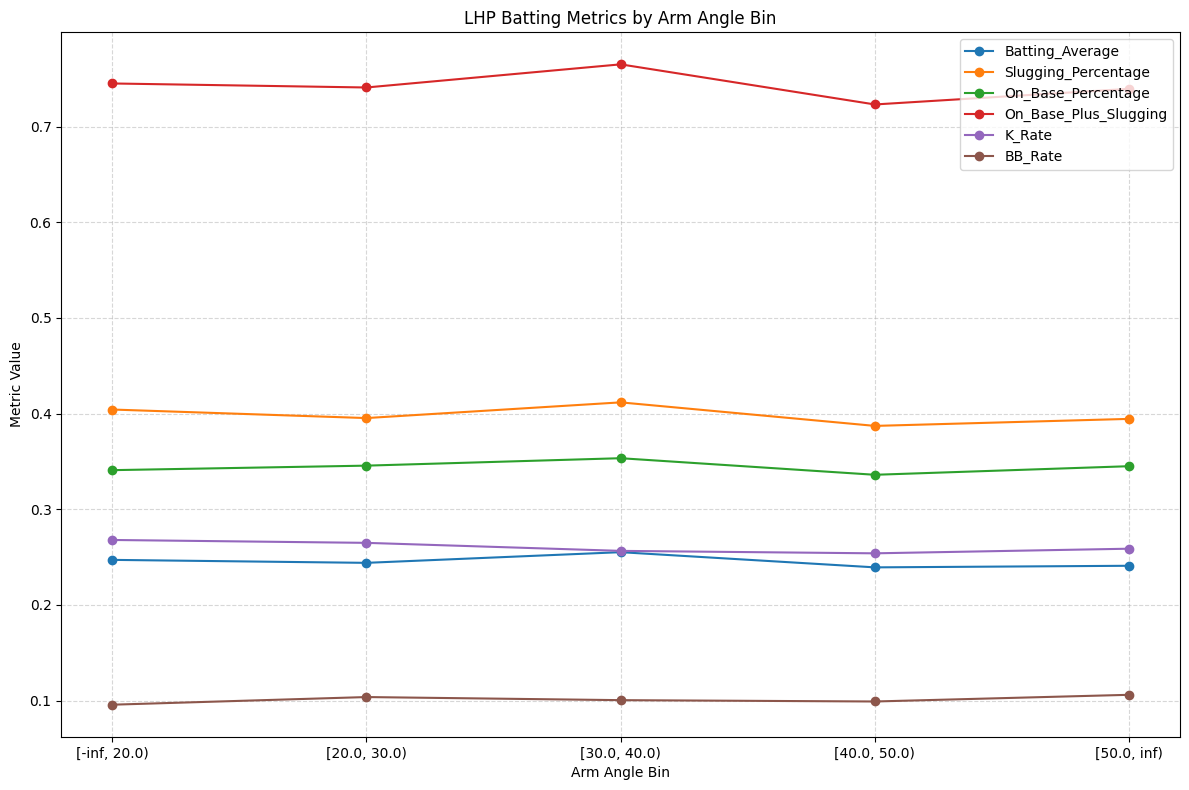

In [65]:
# Select the metrics to plot
metrics = ['Batting_Average', 'Slugging_Percentage', 'On_Base_Percentage', 
           'On_Base_Plus_Slugging', 'K_Rate', 'BB_Rate']

# Get the bin labels from the index
bins = lhp_ba.index.astype(str)

plt.figure(figsize=(12, 8))
for metric in metrics:
    plt.plot(bins, lhp_ba[metric], marker='o', label=metric)

plt.xlabel('Arm Angle Bin')
plt.ylabel('Metric Value')
plt.title('LHP Batting Metrics by Arm Angle Bin')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

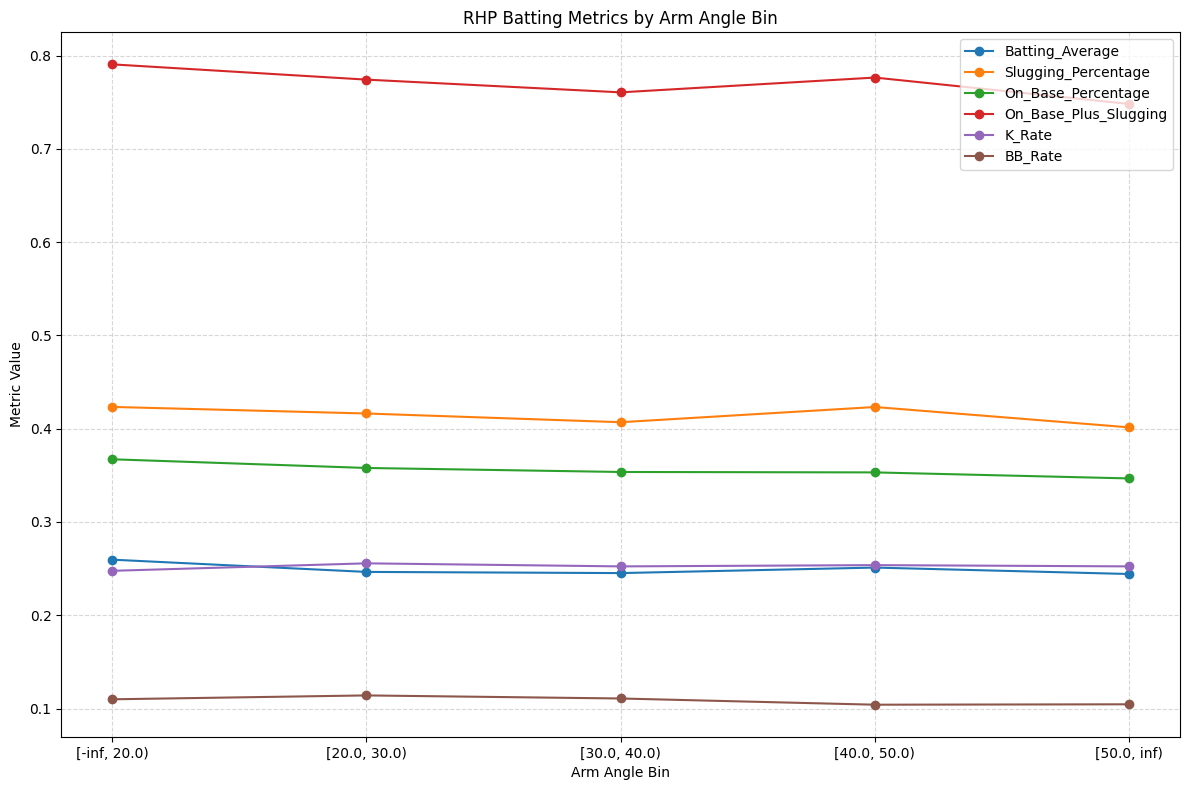

In [66]:
# Select the metrics to plot
metrics = ['Batting_Average', 'Slugging_Percentage', 'On_Base_Percentage', 
           'On_Base_Plus_Slugging', 'K_Rate', 'BB_Rate']

# Get the bin labels from the index
bins = rhp_ba.index.astype(str)

plt.figure(figsize=(12, 8))
for metric in metrics:
    plt.plot(bins, rhp_ba[metric], marker='o', label=metric)

plt.xlabel('Arm Angle Bin')
plt.ylabel('Metric Value')
plt.title('RHP Batting Metrics by Arm Angle Bin')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [84]:

# Example: Analyze Jarren Duran's events by pitcher arm angle bin (2025 season)

duran_id = bb.playerid_lookup('duran', 'jarren')['key_mlbam'][0]
duran_id

# Define 2025 MLB Season
start_date = "2025-03-20"
end_date = "2025-10-05"

# Get Statcast pitch-by-pitch data for Aaron Judge as a batter in the 2025 season
duran_batting_data_2025 = bb.statcast_batter(start_dt=start_date, end_dt=end_date, player_id=duran_id)
duran_batting_data_2025.head()

duran_batting_data_2025_lhp = duran_batting_data_2025[duran_batting_data_2025['p_throws'] == 'L'].copy()
duran_batting_data_2025_rhp = duran_batting_data_2025[duran_batting_data_2025['p_throws'] == 'R'].copy()

duran_batting_data_2025_lhp['arm_angle_bin'] = pd.cut(duran_batting_data_2025_lhp['arm_angle'], bins=arm_angle_bins_custom, right=False)

duran_batting_data_2025_rhp['arm_angle_bin'] = pd.cut(duran_batting_data_2025_rhp['arm_angle'], bins=arm_angle_bins_custom, right=False)



# Group by arm_angle_bin and event and count
duran_events_by_bin = (
    duran_batting_data_2025_rhp
    .groupby(['arm_angle_bin', 'events'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print(f"{batter_name} Events by Arm Angle Bin (Season {season_year}):")
display(duran_events_by_bin)

Gathering Player Data
Jarren Duran Events by Arm Angle Bin (Season 2025):


/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_43330/1505139500.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['arm_angle_bin', 'events'])


events,double,double_play,field_error,field_out,force_out,grounded_into_double_play,hit_by_pitch,home_run,intent_walk,sac_fly,single,strikeout,triple,truncated_pa,walk
arm_angle_bin,,,,,,,,,,,,,,,
"[-inf, 20.0)",1,0,0,19,0,0,0,1,0,0,4,6,1,0,3
"[20.0, 30.0)",9,0,0,27,0,0,3,3,0,1,7,17,3,0,7
"[30.0, 40.0)",6,0,2,56,2,1,3,6,0,1,19,38,1,0,20
"[40.0, 50.0)",14,1,1,57,0,0,2,2,0,0,23,37,3,0,10
"[50.0, inf)",5,0,1,30,1,1,1,1,0,0,9,17,0,1,9
